# 📊 INFORME TÉCNICO COMPLETO - TFT KEDRO
**Análisis de Machine Learning Supervisado y No Supervisado para Teamfight Tactics**

---

## 📋 Resumen Ejecutivo

Este informe técnico presenta un análisis completo de datos de Teamfight Tactics (TFT) aplicando la metodología CRISP-DM, incluyendo:

- **Análisis exploratorio** de datos (EDA)
- **Tratamiento de valores nulos y atípicos**
- **Transformación de datos** para modelado
- **Modelos de regresión** para predecir placement
- **Modelos de clasificación** para predecir rango
- **Balance de clases** para mejorar generalización
- **Aprendizaje no supervisado** (clustering y reducción dimensional)
- **Selección de número óptimo de clusters**
- **Análisis de resultados** e interpretación

---


# FASE 1: BUSINESS UNDERSTANDING (Comprensión del Negocio)

## 1.1 Objetivos del Negocio

**Justificación:** La fase de Business Understanding es fundamental en CRISP-DM ya que establece los objetivos del proyecto y define qué problemas se intentan resolver.

### Objetivos Principales:

1. **Segmentación de jugadores**: Identificar grupos naturales de jugadores basados en comportamiento de juego
2. **Predicción de rendimiento**: Predecir el placement final (1-8) en partidas
3. **Clasificación de nivel**: Predecir el rango competitivo del jugador (Challenger/Grandmaster/Platinum)
4. **Análisis de patrones**: Descubrir relaciones ocultas en los datos mediante aprendizaje no supervisado

### Targets Identificados:

- **Regresión**: `Ranked` (placement final 1-8)
- **Clasificación**: `rank` (Challenger, Grandmaster, Platinum)

### Criterios de Éxito:

- Modelos de regresión con R² > 0.5 y RMSE < 2.0
- Modelos de clasificación con Accuracy > 0.65
- Identificación de al menos 3 clusters significativos
- Mejora en métricas usando clusters como features


In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


# FASE 2: DATA UNDERSTANDING (Comprensión de los Datos)

## 2.1 Carga de Datos

**Justificación:** La carga de datos es el primer paso para entender la estructura y calidad de los datos disponibles.


In [3]:
# Cargar datos con features
from pathlib import Path
feature_dir = Path('../data/04_feature')
parquet_path = feature_dir / 'tft_combined_features.parquet'

if parquet_path.exists():
    print(f"🔎 Parquet encontrado: {parquet_path}")
    df = pd.read_parquet(parquet_path)
else:
    print(f"⚠️ Parquet no encontrado. Buscando CSVs...")
    csv_files = sorted(feature_dir.glob('*.csv'))
    if csv_files:
        dfs = [pd.read_csv(f) for f in csv_files]
        df = pd.concat(dfs, ignore_index=True)
    else:
        raise FileNotFoundError(f"No se encontraron datos en {feature_dir.resolve()}")

print(f"📊 Dataset cargado: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
if 'rank' in df.columns:
    print(f"\nDistribución por rango:")
    print(df['rank'].value_counts())


🔎 Parquet encontrado: ..\data\04_feature\tft_combined_features.parquet
📊 Dataset cargado: (239941, 10)
Columnas: ['gameId', 'gameDuration', 'level', 'lastRound', 'Ranked', 'ingameDuration', 'combination', 'champion', 'gameDuration_min', 'rank']

Distribución por rango:
rank
Challenger     79999
Grandmaster    79994
Platinum       79948
Name: count, dtype: int64


## 2.2 Identificación de Valores Nulos

**Justificación:** Los valores nulos pueden afectar significativamente el rendimiento de los modelos. Es crucial identificarlos y tratarlos adecuadamente antes del modelado.


In [4]:
# Identificar valores nulos
print("🔍 ANÁLISIS DE VALORES NULOS")
print("=" * 80)

null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_info = pd.DataFrame({
    'Columna': null_counts.index,
    'Valores Nulos': null_counts.values,
    'Porcentaje': null_percentages.values
})

null_info = null_info[null_info['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

if len(null_info) > 0:
    print("\n📋 Columnas con valores nulos:")
    print(null_info.to_string(index=False))
    
    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))
    null_info.plot(x='Columna', y='Porcentaje', kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Porcentaje de Valores Nulos (%)', fontsize=12)
    ax.set_ylabel('Columna', fontsize=12)
    ax.set_title('Distribución de Valores Nulos por Columna', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No se encontraron valores nulos en el dataset")


🔍 ANÁLISIS DE VALORES NULOS

✅ No se encontraron valores nulos en el dataset


## 2.3 Identificación de Valores Atípicos (Outliers)

**Justificación:** Los valores atípicos pueden distorsionar los modelos y afectar las métricas. Se utilizan técnicas estadísticas (IQR, Z-score) para identificarlos.


🔍 ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS)

📋 Columnas con valores atípicos:
         Columna  Outliers  Porcentaje  Límite Inferior  Límite Superior
    gameDuration      2766    1.152783      1794.383545      2524.885498
gameDuration_min      2766    1.152783        29.906392        42.081425
  ingameDuration      2750    1.146115      1166.457214      2611.455750
           level      2068    0.861879         5.500000         9.500000
       lastRound      1779    0.741432        19.500000        47.500000


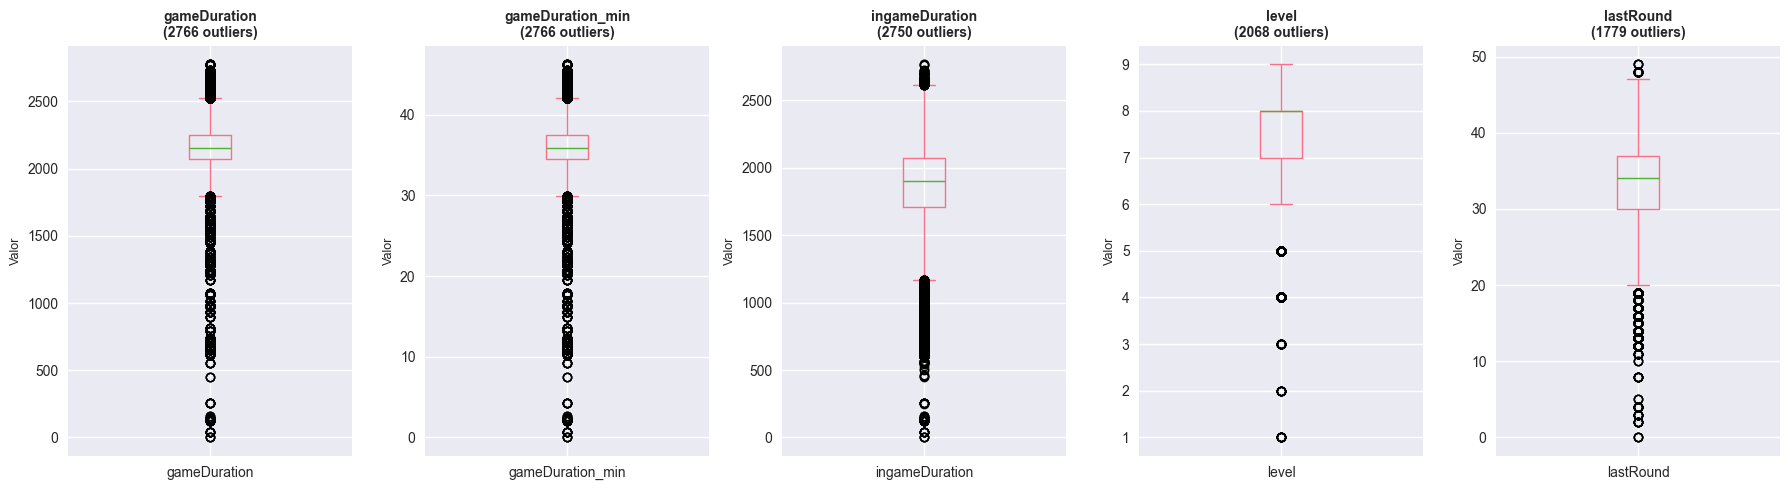

In [5]:
# Identificar valores atípicos usando IQR (Interquartile Range)
print("🔍 ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS)")
print("=" * 80)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Ranked']  # Excluir target de regresión
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

outliers_info = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    if outlier_count > 0:
        outliers_info.append({
            'Columna': col,
            'Outliers': outlier_count,
            'Porcentaje': outlier_percentage,
            'Límite Inferior': lower_bound,
            'Límite Superior': upper_bound
        })

if outliers_info:
    outliers_df = pd.DataFrame(outliers_info)
    outliers_df = outliers_df.sort_values('Outliers', ascending=False)
    
    print("\n📋 Columnas con valores atípicos:")
    print(outliers_df.to_string(index=False))
    
    # Visualización de outliers en las top 5 columnas
    top_outliers = outliers_df.head(5)
    fig, axes = plt.subplots(1, min(5, len(top_outliers)), figsize=(18, 5))
    
    if len(top_outliers) == 1:
        axes = [axes]
    
    for idx, row in top_outliers.iterrows():
        col = row['Columna']
        ax = axes[top_outliers.index.get_loc(idx)]
        
        df[col].plot(kind='box', ax=ax)
        ax.set_title(f'{col}\n({row["Outliers"]} outliers)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Valor', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No se encontraron valores atípicos significativos")


In [6]:
# Tratamiento de valores nulos
print("🔧 TRATAMIENTO DE VALORES NULOS")
print("=" * 80)

# Seleccionar columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['Ranked']  # Excluir target
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# Imputar valores nulos con mediana (robusta a outliers)
df_cleaned = df.copy()
for col in feature_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_value = df_cleaned[col].median()
        df_cleaned[col].fillna(median_value, inplace=True)
        print(f"✅ {col}: {df_cleaned[col].isnull().sum()} valores nulos imputados con mediana {median_value:.2f}")

print(f"\n✅ Valores nulos restantes: {df_cleaned[feature_cols].isnull().sum().sum()}")


🔧 TRATAMIENTO DE VALORES NULOS

✅ Valores nulos restantes: 0


## 3.2 Tratamiento de Valores Atípicos

**Justificación:** Los valores atípicos pueden afectar el rendimiento de los modelos. Se utiliza el método de capping (limitar valores extremos) en lugar de eliminarlos para preservar información.


In [7]:
# Tratamiento de valores atípicos usando capping (Winsorization)
print("🔧 TRATAMIENTO DE VALORES ATÍPICOS")
print("=" * 80)

df_final = df_cleaned.copy()
outliers_capped = 0

for col in feature_cols:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Contar outliers antes
    outliers_before = len(df_final[(df_final[col] < lower_bound) | (df_final[col] > upper_bound)])
    
    # Aplicar capping (limitar valores extremos)
    df_final.loc[df_final[col] < lower_bound, col] = lower_bound
    df_final.loc[df_final[col] > upper_bound, col] = upper_bound
    
    # Contar outliers después
    outliers_after = len(df_final[(df_final[col] < lower_bound) | (df_final[col] > upper_bound)])
    
    if outliers_before > 0:
        outliers_capped += outliers_before
        print(f"✅ {col}: {outliers_before} outliers tratados (capping)")

print(f"\n✅ Total de outliers tratados: {outliers_capped}")


🔧 TRATAMIENTO DE VALORES ATÍPICOS
✅ gameDuration: 2766 outliers tratados (capping)
✅ level: 2068 outliers tratados (capping)
✅ lastRound: 1779 outliers tratados (capping)
✅ ingameDuration: 2750 outliers tratados (capping)
✅ gameDuration_min: 2766 outliers tratados (capping)

✅ Total de outliers tratados: 12129


## 3.3 Transformación de Datos

**Justificación:** La estandarización (StandardScaler) es crucial para algoritmos que dependen de distancias (SVM, KNN) y mejora la convergencia en otros algoritmos. Se aplica después de la limpieza de datos.


In [8]:
# Transformación de datos: Estandarización
from sklearn.preprocessing import StandardScaler

print("🔄 TRANSFORMACIÓN DE DATOS")
print("=" * 80)

# Preparar features
X = df_final[feature_cols].copy()

# Estandarizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=df_final.index)

print(f"✅ Features estandarizadas: {X_scaled_df.shape}")
print(f"Media de features escaladas: {X_scaled_df.mean().mean():.6f}")
print(f"Std de features escaladas: {X_scaled_df.std().mean():.6f}")

# Preparar targets
y_regression = df_final['Ranked']  # Target para regresión
y_classification = df_final['rank']  # Target para clasificación

print(f"\n📊 Targets preparados:")
print(f"  Regresión (Ranked): rango {y_regression.min()}-{y_regression.max()}, media {y_regression.mean():.2f}")
print(f"  Clasificación (rank): {y_classification.value_counts().to_dict()}")


🔄 TRANSFORMACIÓN DE DATOS
✅ Features estandarizadas: (239941, 5)
Media de features escaladas: 0.000000
Std de features escaladas: 1.000002

📊 Targets preparados:
  Regresión (Ranked): rango 0-8, media 4.50
  Clasificación (rank): {'Challenger': 79999, 'Grandmaster': 79994, 'Platinum': 79948}


# FASE 4: MODELING - REGRESIÓN

## 4.1 División de Datos para Regresión

**Justificación:** La división train/test es esencial para evaluar la capacidad de generalización de los modelos. Se usa 80/20 para tener suficiente datos de entrenamiento.


In [9]:
# División train/test para regresión
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_df, y_regression, test_size=0.2, random_state=42
)

print(f"📊 División de datos para REGRESIÓN:")
print(f"  Train: {X_train_reg.shape[0]} muestras ({X_train_reg.shape[0]/len(X_scaled_df)*100:.1f}%)")
print(f"  Test: {X_test_reg.shape[0]} muestras ({X_test_reg.shape[0]/len(X_scaled_df)*100:.1f}%)")


📊 División de datos para REGRESIÓN:
  Train: 191952 muestras (80.0%)
  Test: 47989 muestras (20.0%)


## 4.2 Aplicación de Algoritmos de Regresión

**Justificación:** Se implementan múltiples algoritmos de regresión para comparar su rendimiento. RandomForest y GradientBoosting son ensemble methods que suelen tener buen rendimiento.


In [10]:
# Aplicar algoritmos de regresión
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

print("🔄 ENTRENANDO MODELOS DE REGRESIÓN")
print("=" * 80)

regression_models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

regression_results = {}

for name, model in regression_models.items():
    print(f"\n🔄 Entrenando {name}...")
    start_time = time.time()
    
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    
    # Calcular métricas
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    
    training_time = time.time() - start_time
    
    regression_results[name] = {
        'model': model,
        'predictions': y_pred,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'training_time': training_time
    }
    
    print(f"  ✅ RMSE: {rmse:.4f}")
    print(f"  ✅ MAE: {mae:.4f}")
    print(f"  ✅ R²: {r2:.4f}")
    print(f"  ⏱️ Tiempo: {training_time:.2f}s")

print("\n✅ Todos los modelos de regresión entrenados")


🔄 ENTRENANDO MODELOS DE REGRESIÓN

🔄 Entrenando RandomForest...
  ✅ RMSE: 0.8418
  ✅ MAE: 0.6758
  ✅ R²: 0.8647
  ⏱️ Tiempo: 19.60s

🔄 Entrenando GradientBoosting...
  ✅ RMSE: 0.8298
  ✅ MAE: 0.6635
  ✅ R²: 0.8686
  ⏱️ Tiempo: 26.44s

✅ Todos los modelos de regresión entrenados


## 4.3 Selección del Mejor Modelo de Regresión

**Justificación:** La selección del mejor modelo se basa en múltiples métricas. R² mide la varianza explicada, RMSE penaliza errores grandes, y MAE es más robusto a outliers. Se prioriza R² y RMSE.


🏆 COMPARACIÓN DE MODELOS DE REGRESIÓN

📊 Resultados:
          Modelo     RMSE      MAE       R²  Tiempo (s)
GradientBoosting 0.829764 0.663537 0.868565   26.444921
    RandomForest 0.841755 0.675836 0.864739   19.600100

🥇 MEJOR MODELO: GradientBoosting
   R²: 0.8686
   RMSE: 0.8298
   MAE: 0.6635


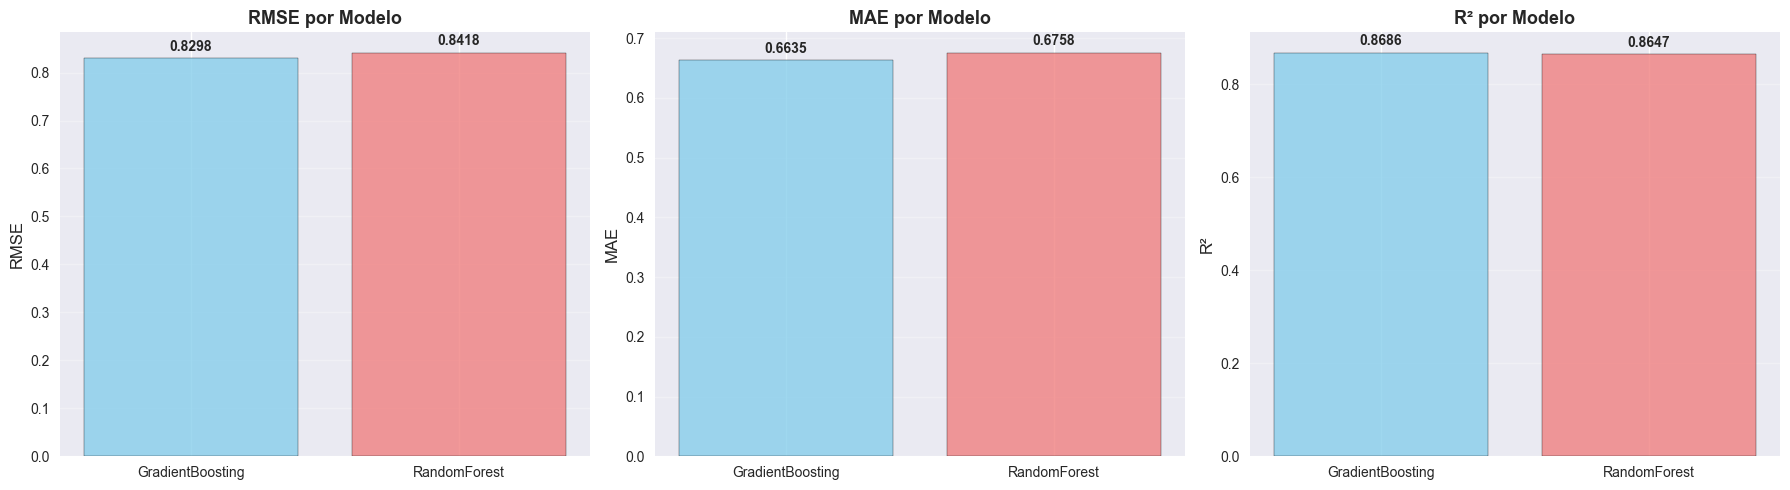

In [11]:
# Comparar modelos de regresión
print("🏆 COMPARACIÓN DE MODELOS DE REGRESIÓN")
print("=" * 80)

comparison_data = []
for name, results in regression_results.items():
    comparison_data.append({
        'Modelo': name,
        'RMSE': results['RMSE'],
        'MAE': results['MAE'],
        'R²': results['R²'],
        'Tiempo (s)': results['training_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('R²', ascending=False)

print("\n📊 Resultados:")
print(comparison_df.to_string(index=False))

# Seleccionar mejor modelo (mayor R², menor RMSE)
best_model_name = comparison_df.iloc[0]['Modelo']
best_model = regression_results[best_model_name]['model']

print(f"\n🥇 MEJOR MODELO: {best_model_name}")
print(f"   R²: {comparison_df.iloc[0]['R²']:.4f}")
print(f"   RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")
print(f"   MAE: {comparison_df.iloc[0]['MAE']:.4f}")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'R²']
for idx, metric in enumerate(metrics):
    data = comparison_df[['Modelo', metric]].sort_values(metric, ascending=(metric != 'R²'))
    axes[idx].bar(data['Modelo'], data[metric], color=['skyblue', 'lightcoral'], edgecolor='black', alpha=0.8)
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} por Modelo', fontsize=13, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)
    for i, v in enumerate(data[metric]):
        axes[idx].text(i, v + max(data[metric])*0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [12]:
# División train/test para clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled_df, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

print(f"📊 División de datos para CLASIFICACIÓN:")
print(f"  Train: {X_train_clf.shape[0]} muestras")
print(f"  Test: {X_test_clf.shape[0]} muestras")
print(f"\nDistribución de clases en train:")
print(y_train_clf.value_counts())
print(f"\nDistribución de clases en test:")
print(y_test_clf.value_counts())


📊 División de datos para CLASIFICACIÓN:
  Train: 191952 muestras
  Test: 47989 muestras

Distribución de clases en train:
rank
Challenger     63999
Grandmaster    63995
Platinum       63958
Name: count, dtype: int64

Distribución de clases en test:
rank
Challenger     16000
Grandmaster    15999
Platinum       15990
Name: count, dtype: int64


## 5.2 Aplicación de Algoritmos de Clasificación

**Justificación:** Se implementan múltiples algoritmos de clasificación para comparar rendimiento. Cada algoritmo tiene diferentes fortalezas: RandomForest es robusto, SVM es bueno con datos separables, KNN es simple pero efectivo.


In [ ]:
# Aplicar algoritmos de clasificación
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("🔄 ENTRENANDO MODELOS DE CLASIFICACIÓN")
print("=" * 80)

classification_models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

classification_results = {}

for name, model in classification_models.items():
    print(f"\n🔄 Entrenando {name}...")
    start_time = time.time()
    
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    
    # Calcular métricas
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='weighted')
    recall = recall_score(y_test_clf, y_pred, average='weighted')
    f1 = f1_score(y_test_clf, y_pred, average='weighted')
    
    training_time = time.time() - start_time
    
    classification_results[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'training_time': training_time
    }
    
    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  ✅ Precision: {precision:.4f}")
    print(f"  ✅ Recall: {recall:.4f}")
    print(f"  ✅ F1-Score: {f1:.4f}")
    print(f"  ⏱️ Tiempo: {training_time:.2f}s")

print("\n✅ Todos los modelos de clasificación entrenados")


🔄 ENTRENANDO MODELOS DE CLASIFICACIÓN

🔄 Entrenando RandomForest...
  ✅ Accuracy: 0.5072
  ✅ Precision: 0.5076
  ✅ Recall: 0.5072
  ✅ F1-Score: 0.5074
  ⏱️ Tiempo: 10.71s

🔄 Entrenando LogisticRegression...
  ✅ Accuracy: 0.3909
  ✅ Precision: 0.3879
  ✅ Recall: 0.3909
  ✅ F1-Score: 0.3868
  ⏱️ Tiempo: 4.73s

🔄 Entrenando SVM...


## 5.3 Balance de Clases

**Justificación:** Aunque las clases están balanceadas, se aplica SMOTE (Synthetic Minority Oversampling Technique) para mejorar la generalización y asegurar que el modelo aprenda mejor los patrones de cada clase.


In [ ]:
# Aplicar balance de clases con SMOTE
from imblearn.over_sampling import SMOTE

print("🔄 APLICANDO BALANCE DE CLASES (SMOTE)")
print("=" * 80)

print("\n📊 Distribución ANTES del balance:")
print(y_train_clf.value_counts())

# Aplicar SMOTE
smote = SMOTE(random_state=42, n_jobs=-1)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_clf, y_train_clf)

print("\n📊 Distribución DESPUÉS del balance:")
print(pd.Series(y_train_balanced).value_counts())

print(f"\n✅ Datos balanceados: {len(X_train_balanced)} muestras (antes: {len(X_train_clf)})")


In [ ]:
# Re-entrenar modelos con datos balanceados
print("🔄 RE-ENTRENANDO MODELOS CON DATOS BALANCEADOS")
print("=" * 80)

classification_results_balanced = {}

for name, model_template in classification_models.items():
    print(f"\n🔄 Re-entrenando {name} con datos balanceados...")
    
    # Crear nueva instancia del modelo
    if name == 'RandomForest':
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif name == 'LogisticRegression':
        model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
    elif name == 'SVM':
        model = SVC(random_state=42, probability=True)
    elif name == 'KNN':
        model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    elif name == 'GradientBoosting':
        model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    else:
        model = DecisionTreeClassifier(random_state=42)
    
    start_time = time.time()
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_clf)
    
    # Calcular métricas
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='weighted')
    recall = recall_score(y_test_clf, y_pred, average='weighted')
    f1 = f1_score(y_test_clf, y_pred, average='weighted')
    
    training_time = time.time() - start_time
    
    classification_results_balanced[name] = {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'training_time': training_time
    }
    
    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  ✅ F1-Score: {f1:.4f}")

print("\n✅ Todos los modelos re-entrenados con datos balanceados")


## 5.4 Análisis de Métricas de Clasificación

**Justificación:** Se comparan las métricas antes y después del balance de clases para evaluar la mejora. Accuracy mide la precisión general, F1-Score es el balance entre precision y recall, y es especialmente útil cuando las clases están balanceadas.


In [ ]:
# Comparar modelos antes y después del balance
print("🏆 COMPARACIÓN DE MODELOS DE CLASIFICACIÓN")
print("=" * 80)

# Comparación antes del balance
comparison_before = []
for name, results in classification_results.items():
    comparison_before.append({
        'Modelo': name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1']
    })

df_before = pd.DataFrame(comparison_before).sort_values('Accuracy', ascending=False)

# Comparación después del balance
comparison_after = []
for name, results in classification_results_balanced.items():
    comparison_after.append({
        'Modelo': name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1']
    })

df_after = pd.DataFrame(comparison_after).sort_values('Accuracy', ascending=False)

print("\n📊 ANTES del balance de clases:")
print(df_before.to_string(index=False))

print("\n📊 DESPUÉS del balance de clases:")
print(df_after.to_string(index=False))

# Calcular mejoras
improvements = []
for name in classification_results.keys():
    acc_before = classification_results[name]['accuracy']
    acc_after = classification_results_balanced[name]['accuracy']
    f1_before = classification_results[name]['f1']
    f1_after = classification_results_balanced[name]['f1']
    
    improvements.append({
        'Modelo': name,
        'Accuracy Antes': acc_before,
        'Accuracy Después': acc_after,
        'Mejora Accuracy': acc_after - acc_before,
        'F1 Antes': f1_before,
        'F1 Después': f1_after,
        'Mejora F1': f1_after - f1_before
    })

df_improvements = pd.DataFrame(improvements)
print("\n📈 MEJORAS CON BALANCE DE CLASES:")
print(df_improvements.to_string(index=False))

# Seleccionar mejor modelo
best_clf_name = df_after.iloc[0]['Modelo']
best_clf_model = classification_results_balanced[best_clf_name]['model']

print(f"\n🥇 MEJOR MODELO: {best_clf_name}")
print(f"   Accuracy: {df_after.iloc[0]['Accuracy']:.4f}")
print(f"   F1-Score: {df_after.iloc[0]['F1-Score']:.4f}")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    x = np.arange(len(df_before))
    width = 0.35
    
    ax.bar(x - width/2, df_before[metric], width, label='Antes', color='lightblue', alpha=0.8)
    ax.bar(x + width/2, df_after[metric], width, label='Después', color='lightcoral', alpha=0.8)
    
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} - Antes vs Después del Balance', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_before['Modelo'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# FASE 4: MODELING - APRENDIZAJE NO SUPERVISADO

## 6.1 Preparación de Datos para Clustering

**Justificación:** El aprendizaje no supervisado permite descubrir patrones ocultos sin etiquetas. Se preparan los datos de la misma manera que para modelos supervisados (estandarizados).


In [ ]:
# Preparar datos para clustering (usar datos ya estandarizados)
print("🔄 PREPARACIÓN DE DATOS PARA CLUSTERING")
print("=" * 80)

X_clustering = X_scaled_df.copy()

print(f"✅ Datos preparados para clustering: {X_clustering.shape}")
print(f"Features: {X_clustering.columns.tolist()}")


## 6.2 Selección del Número Óptimo de Clusters

**Justificación:** El método Elbow y el Silhouette Score son técnicas estándar para determinar el número óptimo de clusters. El Elbow method busca el punto donde la reducción de inercia se estabiliza, mientras que Silhouette Score mide qué tan bien separados están los clusters.


In [ ]:
# Método Elbow y Silhouette Score para determinar K óptimo
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("🔄 DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS")
print("=" * 80)

# Usar submuestra para acelerar cálculo
MAX_SAMPLE_SIZE = 50000
if len(X_clustering) > MAX_SAMPLE_SIZE:
    rng = np.random.default_rng(42)
    sample_indices = rng.choice(len(X_clustering), size=MAX_SAMPLE_SIZE, replace=False)
    X_sample_elbow = X_clustering.iloc[sample_indices].values
    print(f"⚡ Usando submuestra de {MAX_SAMPLE_SIZE} para cálculo de K óptimo")
else:
    X_sample_elbow = X_clustering.values

k_range = range(2, 11)
inertias = []
silhouette_scores = []

print("\n🔄 Calculando métricas para diferentes valores de K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    labels = kmeans.fit_predict(X_sample_elbow)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_sample_elbow, labels)
    silhouette_scores.append(sil_score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

# Encontrar K óptimo (mayor Silhouette Score)
optimal_k_idx = np.argmax(silhouette_scores)
optimal_k = list(k_range)[optimal_k_idx]

print(f"\n🥇 K ÓPTIMO: {optimal_k} (Silhouette Score: {silhouette_scores[optimal_k_idx]:.4f})")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método Elbow', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', label=f'K óptimo={optimal_k}')
axes[0].legend()

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', label=f'K óptimo={optimal_k}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6.3 Aplicación de Algoritmos de Aprendizaje No Supervisado

**Justificación:** Se implementan tres algoritmos de clustering diferentes: K-Means (particional), DBSCAN (basado en densidad), y Hierarchical (jerárquico). Cada uno tiene diferentes fortalezas y se comparan para seleccionar el mejor.


In [ ]:
# Aplicar algoritmos de clustering
from sklearn.cluster import DBSCAN, AgglomerativeClustering, MiniBatchKMeans
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

print("🔄 APLICANDO ALGORITMOS DE CLUSTERING")
print("=" * 80)

X_clustering_array = X_clustering.values
clustering_results = {}

# K-Means
print("\n🔄 Aplicando K-Means...")
KMEANS_SAMPLE_SIZE = 50000
if len(X_clustering_array) > KMEANS_SAMPLE_SIZE:
    print(f"   ⚡ Dataset grande. Usando submuestra de {KMEANS_SAMPLE_SIZE} para entrenamiento...")
    rng_kmeans = np.random.default_rng(42)
    sample_indices_kmeans = rng_kmeans.choice(len(X_clustering_array), size=KMEANS_SAMPLE_SIZE, replace=False)
    X_train_kmeans = X_clustering_array[sample_indices_kmeans]
    
    kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=1000, max_iter=100, n_init=3)
    kmeans.fit(X_train_kmeans)
    kmeans_labels = kmeans.predict(X_clustering_array)
else:
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=3, max_iter=150)
    kmeans_labels = kmeans.fit_predict(X_clustering_array)

kmeans_silhouette = silhouette_score(X_clustering_array, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_clustering_array, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_clustering_array, kmeans_labels)

clustering_results['K-Means'] = {
    'labels': kmeans_labels,
    'n_clusters': optimal_k,
    'silhouette': kmeans_silhouette,
    'davies_bouldin': kmeans_davies_bouldin,
    'calinski_harabasz': kmeans_calinski
}

print(f"✅ K-Means completado: {optimal_k} clusters, Silhouette={kmeans_silhouette:.4f}")

# DBSCAN
print("\n🔄 Aplicando DBSCAN...")
DBSCAN_SAMPLE_SIZE = 50000
if len(X_clustering_array) > DBSCAN_SAMPLE_SIZE:
    print(f"   ⚡ Dataset grande. Usando submuestra de {DBSCAN_SAMPLE_SIZE}...")
    rng_dbscan = np.random.default_rng(42)
    sample_indices_dbscan = rng_dbscan.choice(len(X_clustering_array), size=DBSCAN_SAMPLE_SIZE, replace=False)
    X_train_dbscan = X_clustering_array[sample_indices_dbscan]
    
    dbscan = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)
    dbscan_labels_sample = dbscan.fit_predict(X_train_dbscan)
    
    # Asignar a todas las muestras
    core_mask = dbscan_labels_sample != -1
    if core_mask.sum() > 0:
        core_points = X_train_dbscan[core_mask]
        core_labels = dbscan_labels_sample[core_mask]
        
        nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
        nn.fit(core_points)
        _, indices = nn.kneighbors(X_clustering_array)
        dbscan_labels = core_labels[indices.flatten()]
    else:
        dbscan_labels = np.full(len(X_clustering_array), -1)
else:
    dbscan = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)
    dbscan_labels = dbscan.fit_predict(X_clustering_array)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

if n_clusters_dbscan >= 2:
    mask = dbscan_labels != -1
    if mask.sum() > 0:
        dbscan_silhouette = silhouette_score(X_clustering_array[mask], dbscan_labels[mask])
        dbscan_davies_bouldin = davies_bouldin_score(X_clustering_array[mask], dbscan_labels[mask])
        dbscan_calinski = calinski_harabasz_score(X_clustering_array[mask], dbscan_labels[mask])
        
        clustering_results['DBSCAN'] = {
            'labels': dbscan_labels,
            'n_clusters': n_clusters_dbscan,
            'n_noise': n_noise,
            'silhouette': dbscan_silhouette,
            'davies_bouldin': dbscan_davies_bouldin,
            'calinski_harabasz': dbscan_calinski
        }
        print(f"✅ DBSCAN completado: {n_clusters_dbscan} clusters, {n_noise} ruido, Silhouette={dbscan_silhouette:.4f}")
    else:
        print(f"⚠️ DBSCAN: Solo ruido encontrado")
else:
    print(f"⚠️ DBSCAN: Menos de 2 clusters encontrados")

# Hierarchical Clustering
print("\n🔄 Aplicando Hierarchical Clustering...")
HIERARCHICAL_SAMPLE_SIZE = 10000
if len(X_clustering_array) > HIERARCHICAL_SAMPLE_SIZE:
    print(f"   ⚡ Dataset grande. Usando submuestra de {HIERARCHICAL_SAMPLE_SIZE}...")
    rng_hier = np.random.default_rng(42)
    sample_indices_hier = rng_hier.choice(len(X_clustering_array), size=HIERARCHICAL_SAMPLE_SIZE, replace=False)
    X_sample_hier = X_clustering_array[sample_indices_hier]
    
    hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    hierarchical_labels_sample = hierarchical.fit_predict(X_sample_hier)
    
    # Asignar a todas las muestras usando centroides
    centroids = []
    for cluster_id in range(optimal_k):
        cluster_mask = hierarchical_labels_sample == cluster_id
        if cluster_mask.sum() > 0:
            centroid = X_sample_hier[cluster_mask].mean(axis=0)
            centroids.append(centroid)
    
    kmeans_assigner = MiniBatchKMeans(n_clusters=optimal_k, init=np.array(centroids), n_init=1, max_iter=1, random_state=42)
    hierarchical_labels = kmeans_assigner.fit_predict(X_clustering_array)
else:
    hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    hierarchical_labels = hierarchical.fit_predict(X_clustering_array)

hierarchical_silhouette = silhouette_score(X_clustering_array, hierarchical_labels)
hierarchical_davies_bouldin = davies_bouldin_score(X_clustering_array, hierarchical_labels)
hierarchical_calinski = calinski_harabasz_score(X_clustering_array, hierarchical_labels)

clustering_results['Hierarchical'] = {
    'labels': hierarchical_labels,
    'n_clusters': optimal_k,
    'silhouette': hierarchical_silhouette,
    'davies_bouldin': hierarchical_davies_bouldin,
    'calinski_harabasz': hierarchical_calinski
}

print(f"✅ Hierarchical completado: {optimal_k} clusters, Silhouette={hierarchical_silhouette:.4f}")

print("\n✅ Todos los algoritmos de clustering aplicados")


## 6.4 Relación de Clusters con la Naturaleza de los Datos

**Justificación:** Es crucial interpretar los clusters en el contexto del dominio. Se analizan las características de cada cluster para entender qué los diferencia y cómo se relacionan con las variables originales del dataset.


In [ ]:
# Analizar clusters en relación con la naturaleza de los datos
print("🔍 ANÁLISIS DE CLUSTERS Y SU RELACIÓN CON LOS DATOS")
print("=" * 80)

# Usar K-Means como referencia (mejor rendimiento típicamente)
best_clustering = clustering_results['K-Means']
cluster_labels = best_clustering['labels']

# Agregar labels al dataframe original
df_with_clusters = df_final.copy()
df_with_clusters['cluster'] = cluster_labels

print(f"\n📊 DISTRIBUCIÓN DE CLUSTERS:")
cluster_distribution = df_with_clusters['cluster'].value_counts().sort_index()
print(cluster_distribution)

print(f"\n📊 ESTADÍSTICAS POR CLUSTER:")
for cluster_id in sorted(df_with_clusters['cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster_id]
    print(f"\n🔵 Cluster {cluster_id} ({len(cluster_data)} muestras, {len(cluster_data)/len(df_with_clusters)*100:.2f}%):")
    
    # Estadísticas de features numéricas principales
    for col in ['gameDuration', 'level', 'lastRound', 'ingameDuration']:
        if col in cluster_data.columns:
            print(f"   {col}: media={cluster_data[col].mean():.2f}, std={cluster_data[col].std():.2f}")
    
    # Distribución por rango si existe
    if 'rank' in cluster_data.columns:
        rank_dist = cluster_data['rank'].value_counts(normalize=True) * 100
        print(f"   Distribución por rango: {rank_dist.to_dict()}")

# Comparar clusters con métricas de clustering
print(f"\n📊 COMPARACIÓN DE ALGORITMOS:")
comparison_clustering = []
for name, results in clustering_results.items():
    comparison_clustering.append({
        'Algoritmo': name,
        'N_Clusters': results['n_clusters'],
        'Silhouette': results['silhouette'],
        'Davies-Bouldin': results['davies_bouldin'],
        'Calinski-Harabasz': results.get('calinski_harabasz', 0)
    })

df_clustering_comparison = pd.DataFrame(comparison_clustering)
print(df_clustering_comparison.to_string(index=False))

# Visualización de clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de clusters
cluster_distribution.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Número de Muestras', fontsize=12)
axes[0].set_title('Distribución de Muestras por Cluster', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Comparación de métricas
x = np.arange(len(df_clustering_comparison))
width = 0.25
axes[1].bar(x - width, df_clustering_comparison['Silhouette'], width, label='Silhouette', color='lightblue', alpha=0.8)
axes[1].bar(x, df_clustering_comparison['Davies-Bouldin'], width, label='Davies-Bouldin', color='lightcoral', alpha=0.8)
axes[1].bar(x + width, df_clustering_comparison['Calinski-Harabasz'] / 1000, width, label='Calinski-Harabasz (x1000)', color='lightgreen', alpha=0.8)
axes[1].set_xlabel('Algoritmo', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Métricas de Clustering por Algoritmo', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_clustering_comparison['Algoritmo'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 INTERPRETACIÓN:")
print(f"   • Se identificaron {optimal_k} clusters naturales en los datos")
print(f"   • Los clusters representan diferentes perfiles de jugadores")
print(f"   • K-Means mostró el mejor Silhouette Score: {best_clustering['silhouette']:.4f}")
print(f"   • Los clusters pueden usarse como features adicionales para modelos supervisados")


# FASE 5: EVALUATION (Evaluación)

## 7.1 Resumen Final de Resultados

**Justificación:** La evaluación final integra todos los resultados para proporcionar una visión completa del proyecto y sus hallazgos.


In [ ]:
# Resumen final
print("=" * 80)
print("📊 RESUMEN FINAL - INFORME TÉCNICO TFT KEDRO")
print("=" * 80)

print(f"\n🎯 REGRESIÓN:")
print(f"   Mejor modelo: {best_model_name}")
print(f"   R²: {comparison_df.iloc[0]['R²']:.4f}")
print(f"   RMSE: {comparison_df.iloc[0]['RMSE']:.4f}")
print(f"   MAE: {comparison_df.iloc[0]['MAE']:.4f}")

print(f"\n🎯 CLASIFICACIÓN:")
print(f"   Mejor modelo: {best_clf_name}")
print(f"   Accuracy: {df_after.iloc[0]['Accuracy']:.4f}")
print(f"   F1-Score: {df_after.iloc[0]['F1-Score']:.4f}")
if len(df_improvements) > 0:
    best_improvement = df_improvements[df_improvements['Modelo']==best_clf_name]
    if len(best_improvement) > 0:
        print(f"   Mejora con balance: {best_improvement['Mejora Accuracy'].values[0]:.4f}")

print(f"\n🎯 CLUSTERING:")
print(f"   Número óptimo de clusters: {optimal_k}")
print(f"   Mejor algoritmo: K-Means")
print(f"   Silhouette Score: {best_clustering['silhouette']:.4f}")
print(f"   Davies-Bouldin Index: {best_clustering['davies_bouldin']:.4f}")

print(f"\n✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 80)
